# ISIC 2019 Skin Lesion Classification: ConvNeXt + TTA + Fold Ensembling (v2)

Production-grade PyTorch pipeline for 8-class skin lesion classification.

**What is different from v1**
- `ConvNeXt` backbone (timm) with a custom head, `drop_path` stochastic depth
- Layer-wise LR decay + true progressive unfreezing (no optimizer state resets)
- Soft-target Focal Loss so **MixUp / CutMix / label smoothing** are all mathematically correct
- Model EMA (exponential moving average weights) validated alongside raw weights
- 8x dihedral **Test-Time Augmentation** and **multi-fold ensembling**
- Out-of-fold (OOF) evaluation + per-class logit adjustment tuned for macro-F1
- Version-tolerant `albumentations` and `torch.amp` wrappers so it runs on old and new installs

**Honest expectation setting:** strong ISIC 2019 solutions land around 0.93-0.96 weighted accuracy/F1, but
**macro F1 across all 8 classes typically sits in the 0.80-0.88 range** because DF/VASC/SCC are tiny classes.
Anything claiming 0.90+ macro F1 on every class is usually leaking data across folds. This notebook reports
both numbers so you can see the difference.

## 1. Environment

Run once per machine. Pinned loosely so it resolves on Kaggle, Colab, and local CUDA boxes.

In [1]:
!pip install -q "timm>=0.9.12" "albumentations>=1.3.1" "opencv-python-headless" \
    "scikit-learn>=1.3" seaborn kaggle ipywidgets

## 2. Kaggle credentials + dataset download

Three supported paths, checked in order:
1. `kaggle.json` already at `~/.kaggle/kaggle.json`
2. Environment variables `KAGGLE_USERNAME` / `KAGGLE_KEY`
3. Interactive upload widget (run the widget cell, then re-run the download cell)

In [2]:
import json
import os
import stat
import zipfile
from pathlib import Path

KAGGLE_DIR = Path.home() / ".kaggle"
KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"
DATA_ROOT = Path("./data")
EXTRACT_DIR = DATA_ROOT / "isic_2019"

KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)


def credentials_ready() -> bool:
    """True if the Kaggle API can authenticate without further input."""
    if KAGGLE_JSON.exists():
        return True
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    return False


def write_credentials_from_env() -> None:
    """Materialize kaggle.json from environment variables, if present."""
    username = os.environ.get("KAGGLE_USERNAME")
    key = os.environ.get("KAGGLE_KEY")
    if username and key and not KAGGLE_JSON.exists():
        KAGGLE_JSON.write_text(json.dumps({"username": username, "key": key}))
        KAGGLE_JSON.chmod(stat.S_IRUSR | stat.S_IWUSR)  # 0600, required by the API
        print("Wrote kaggle.json from environment variables.")


write_credentials_from_env()
print("Credentials ready:", credentials_ready())

Credentials ready: False


In [3]:
import os
from pathlib import Path

# بررسی پوشه‌های موجود در input
input_path = Path('/kaggle/input')
contents = os.listdir(input_path)

if contents:
    # انتخاب خودکار پوشه اصلی دیتاست
    DATASET_PATH = input_path / contents[0]
    print(f"✅ دیتاست پیدا شد! مسیر دقیق: {DATASET_PATH}")
    print("\nمحتویات داخل پوشه دیتاست:")
    print(os.listdir(DATASET_PATH))
else:
    print("❌ هیچ دیتاستی در /kaggle/input یافت نشد.")
    

✅ دیتاست پیدا شد! مسیر دقیق: /kaggle/input/datasets

محتویات داخل پوشه دیتاست:
['andrewmvd']


## 3. Imports, determinism, configuration

In [4]:
import gc
import math
import random
import re
import warnings
from copy import deepcopy
from dataclasses import dataclass, field, replace
from typing import Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

import albumentations as A
import timm
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
cv2.setNumThreads(0)  # avoid CPU oversubscription inside DataLoader workers

print("torch:", torch.__version__)
print("timm:", timm.__version__)
print("albumentations:", A.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
timm: 1.0.26
albumentations: 2.0.8
cuda available: True


In [5]:
def seed_everything(seed: int = 42) -> None:
    """Make runs reproducible while keeping cudnn autotuning for speed."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_CLASSES: List[str] = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
NUM_CLASSES = len(TARGET_CLASSES)


@dataclass
class Config:
    """Single source of truth for the whole pipeline."""

    # data
    data_dir: Path = EXTRACT_DIR
    image_size: int = 320                      # ConvNeXt is resolution-flexible; 320 is a good accuracy/VRAM trade
    batch_size: int = 16
    val_batch_size: int = 32
    num_workers: int = 4
    num_folds: int = 5
    folds_to_run: Tuple[int, ...] = (0,)       # e.g. (0, 1, 2, 3, 4) for the full ensemble

    # model
    model_name: str = "convnext_base.fb_in22k_ft_in1k"
    pretrained: bool = True
    drop_path_rate: float = 0.2
    head_dropout: float = 0.3

    # optimization
    epochs: int = 15
    base_lr: float = 3e-4                      # head LR; backbone gets scaled down by layer decay
    layer_decay: float = 0.75
    weight_decay: float = 0.05
    warmup_epochs: int = 1
    min_lr: float = 1e-6
    scheduler_t0: int = 5
    scheduler_tmult: int = 1
    max_grad_norm: float = 1.0
    mixed_precision: bool = True
    channels_last: bool = True

    # progressive unfreezing: epoch -> lowest trainable layer group id
    unfreeze_schedule: Dict[int, int] = field(
        default_factory=lambda: {0: 99, 1: 4, 3: 3, 5: 2, 7: 0}
    )

    # regularization / imbalance
    label_smoothing: float = 0.05
    mixup_alpha: float = 0.4
    cutmix_alpha: float = 1.0
    mix_prob: float = 0.5                      # chance a batch gets MixUp or CutMix
    focal_gamma: float = 2.0
    class_weight_power: float = 0.5            # 0 = none, 0.5 = sqrt-inverse, 1 = full inverse
    use_weighted_sampler: bool = True

    # EMA + early stopping
    use_ema: bool = True
    ema_decay: float = 0.9995
    early_stopping_patience: int = 5

    # inference
    use_tta: bool = True
    tta_transforms: int = 8                    # 8 = full dihedral group

    # io
    checkpoint_dir: Path = Path("./checkpoints")


CFG = Config()
CFG.checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(CFG)

Config(data_dir=PosixPath('data/isic_2019'), image_size=320, batch_size=16, val_batch_size=32, num_workers=4, num_folds=5, folds_to_run=(0,), model_name='convnext_base.fb_in22k_ft_in1k', pretrained=True, drop_path_rate=0.2, head_dropout=0.3, epochs=15, base_lr=0.0003, layer_decay=0.75, weight_decay=0.05, warmup_epochs=1, min_lr=1e-06, scheduler_t0=5, scheduler_tmult=1, max_grad_norm=1.0, mixed_precision=True, channels_last=True, unfreeze_schedule={0: 99, 1: 4, 3: 3, 5: 2, 7: 0}, label_smoothing=0.05, mixup_alpha=0.4, cutmix_alpha=1.0, mix_prob=0.5, focal_gamma=2.0, class_weight_power=0.5, use_weighted_sampler=True, use_ema=True, ema_decay=0.9995, early_stopping_patience=5, use_tta=True, tta_transforms=8, checkpoint_dir=PosixPath('checkpoints'))


## 4. Metadata discovery and label normalization

The Kaggle mirror's folder layout shifts between versions, so we discover the ground-truth CSV and the
image directory instead of hardcoding paths.

In [6]:
import os
from pathlib import Path

# شناسایی خودکار پوشه دیتاسِت اضافه شده در Kaggle
input_path = Path("/kaggle/input")
subfolders = [f for f in input_path.iterdir() if f.is_dir()]

if subfolders:
    # به‌روزرسانی مسیر CFG.data_dir به پوشه واقعی در کگل
    CFG.data_dir = subfolders[0]
    print(f"✅ مسیر با موفقیت جایگزین شد: {CFG.data_dir}")
else:
    print("❌ هیچ پوشه‌ای در مسیر /kaggle/input یافت نشد. بررسی کنید که Add Data انجام شده باشد.")
    

✅ مسیر با موفقیت جایگزین شد: /kaggle/input/datasets


In [7]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}


def find_ground_truth_csv(root: Path) -> Path:
    """Pick the CSV most likely to hold the one-hot diagnosis labels."""
    candidates = sorted(root.rglob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No CSV files under {root}")

    def score(path: Path) -> Tuple[int, int]:
        name = path.name.lower()
        keyword_score = sum(
            keyword in name
            for keyword in ("groundtruth", "ground_truth", "training", "train", "labels")
        )
        # Metadata-only files (age/sex/site) are a weaker match than label files.
        penalty = -2 if "metadata" in name else 0
        return keyword_score + penalty, path.stat().st_size

    return max(candidates, key=score)


def find_image_dir(root: Path) -> Path:
    """Pick the directory holding the most image files."""
    counts: Dict[Path, int] = {}
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES:
            counts[path.parent] = counts.get(path.parent, 0) + 1
    if not counts:
        raise FileNotFoundError(f"No images under {root}")
    return max(counts.items(), key=lambda item: item[1])[0]


GT_CSV = find_ground_truth_csv(CFG.data_dir)
IMAGE_DIR = find_image_dir(CFG.data_dir)
print("Ground-truth CSV:", GT_CSV)
print("Image directory :", IMAGE_DIR)

df_raw = pd.read_csv(GT_CSV)
print("Raw shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.head())

Ground-truth CSV: /kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv
Image directory : /kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
Raw shape: (25331, 10)
Columns: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
def build_dataframe(df: pd.DataFrame, image_dir: Path) -> pd.DataFrame:
    """Convert one-hot ISIC labels into a tidy single-label dataframe with resolved paths."""
    frame = df.copy()
    frame.columns = [str(col).strip() for col in frame.columns]

    id_col = next(
        (col for col in ("image", "image_name", "image_id", "isic_id") if col in frame.columns),
        None,
    )
    if id_col is None:
        raise ValueError(f"No image id column found in {list(frame.columns)}")

    # Match label columns case-insensitively, then normalize to canonical names.
    lookup = {col.upper(): col for col in frame.columns}
    missing = [name for name in TARGET_CLASSES if name not in lookup]
    if missing:
        raise ValueError(f"Missing label columns {missing}. Found: {list(frame.columns)}")
    label_cols = [lookup[name] for name in TARGET_CLASSES]

    onehot = frame[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    # Drop UNK rows and any multi-label rows: exactly one positive is required.
    keep = onehot.sum(axis=1).eq(1.0)
    frame = frame.loc[keep].reset_index(drop=True)
    onehot = onehot.loc[keep].reset_index(drop=True)

    frame["label_str"] = [TARGET_CLASSES[i] for i in onehot.values.argmax(axis=1)]
    frame["label"] = frame["label_str"].map({name: i for i, name in enumerate(TARGET_CLASSES)})

    # Index the image directory once instead of stat-ing per row (much faster on 25k files).
    index = {
        path.stem: str(path)
        for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    }
    frame["image_path"] = frame[id_col].astype(str).str.strip().map(index)

    unresolved = int(frame["image_path"].isna().sum())
    if unresolved:
        print(f"WARNING: dropping {unresolved} rows with no matching image file.")
    frame = frame.dropna(subset=["image_path"]).reset_index(drop=True)

    if frame.empty:
        raise RuntimeError("No rows survived path resolution. Check the extracted layout.")

    return frame[[id_col, "image_path", "label_str", "label"]].rename(columns={id_col: "image_id"})


df_data = build_dataframe(df_raw, IMAGE_DIR)
print("Usable samples:", len(df_data))
display(df_data["label_str"].value_counts().rename("count").to_frame())
display(df_data.head())

Usable samples: 25331


,count
label_str,
NV,12875
MEL,4522
BCC,3323
BKL,2624
AK,867
SCC,628
VASC,253
DF,239


,image_id,image_path,label_str,label
0,ISIC_0000000,/kaggle/input/datasets/andrewmvd/isic-2019/ISI...,NV,1
1,ISIC_0000001,/kaggle/input/datasets/andrewmvd/isic-2019/ISI...,NV,1
2,ISIC_0000002,/kaggle/input/datasets/andrewmvd/isic-2019/ISI...,MEL,0
3,ISIC_0000003,/kaggle/input/datasets/andrewmvd/isic-2019/ISI...,NV,1
4,ISIC_0000004,/kaggle/input/datasets/andrewmvd/isic-2019/ISI...,MEL,0


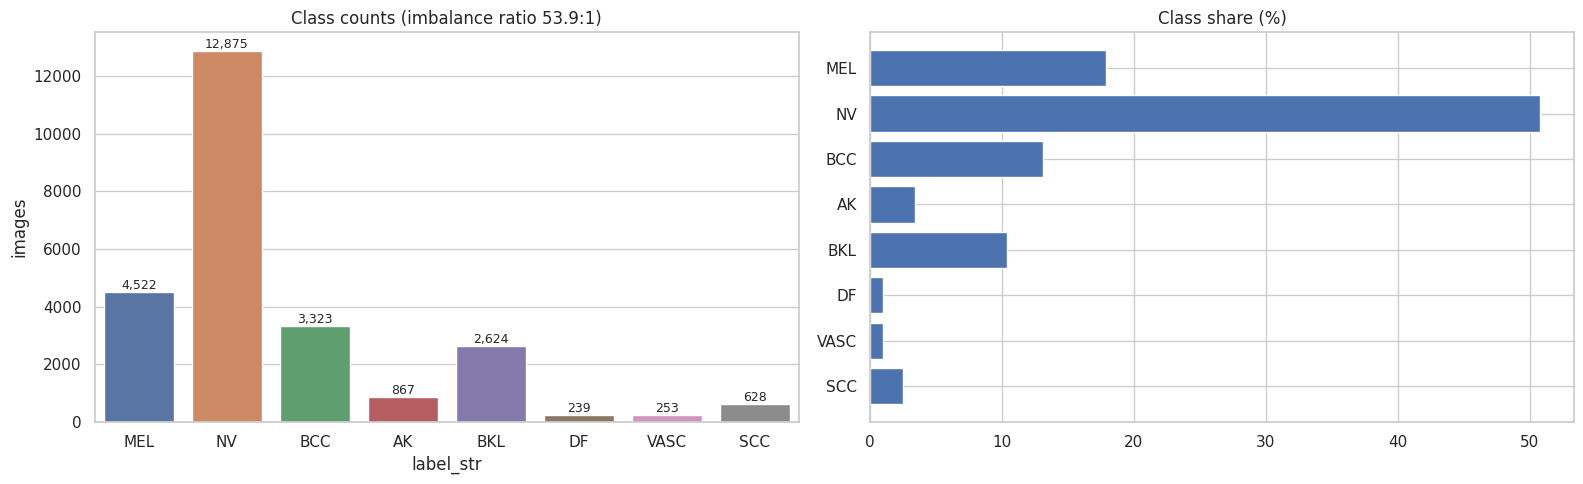

In [9]:
def plot_class_distribution(frame: pd.DataFrame) -> None:
    """Show how brutal the imbalance actually is."""
    counts = frame["label_str"].value_counts().reindex(TARGET_CLASSES)
    ratio = counts.max() / counts.min()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], hue=counts.index, legend=False)
    axes[0].set_title(f"Class counts (imbalance ratio {ratio:.1f}:1)")
    axes[0].set_ylabel("images")
    for i, value in enumerate(counts.values):
        axes[0].text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

    axes[1].barh(counts.index[::-1], (counts.values / counts.sum() * 100)[::-1])
    axes[1].set_title("Class share (%)")
    plt.tight_layout()
    plt.show()


plot_class_distribution(df_data)

## 5. Stratified K-Fold

Folds are assigned once, up front, so every experiment shares the same splits and OOF predictions
stay comparable.

In [10]:
def assign_folds(frame: pd.DataFrame, num_folds: int, seed: int) -> pd.DataFrame:
    """Add a stratified `fold` column."""
    frame = frame.copy()
    frame["fold"] = -1
    splitter = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
    for fold, (_, val_idx) in enumerate(splitter.split(frame, frame["label"])):
        frame.loc[val_idx, "fold"] = fold
    assert (frame["fold"] >= 0).all(), "Every row must land in a fold."
    return frame


df_data = assign_folds(df_data, CFG.num_folds, SEED)
display(pd.crosstab(df_data["fold"], df_data["label_str"])[TARGET_CLASSES])

label_str,MEL,NV,BCC,AK,BKL,DF,VASC,SCC
fold,,,,,,,,
0,905,2575,665,174,525,47,50,126
1,905,2575,664,173,524,48,51,126
2,904,2575,664,173,525,48,51,126
3,904,2575,665,173,525,48,51,125
4,904,2575,665,174,525,48,50,125


## 6. Augmentation pipeline

`albumentations` renamed several arguments across 1.3 -> 1.4 -> 2.x. The helpers below try the modern
signature and fall back to the legacy one, so this cell never raises on a version mismatch.

In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def _try_build(*factories):
    """Return the first transform that constructs cleanly across albumentations versions."""
    errors = []
    for factory in factories:
        try:
            return factory()
        except (TypeError, ValueError) as exc:
            errors.append(str(exc))
    raise RuntimeError("No compatible transform signature found: " + " | ".join(errors))


def coarse_dropout(p: float = 0.5) -> A.BasicTransform:
    """Cutout, compatible with old and new albumentations."""
    return _try_build(
        lambda: A.CoarseDropout(
            num_holes_range=(1, 8),
            hole_height_range=(0.05, 0.15),
            hole_width_range=(0.05, 0.15),
            fill=0,
            p=p,
        ),
        lambda: A.CoarseDropout(
            max_holes=8, max_height=48, max_width=48, min_holes=1, fill_value=0, p=p
        ),
    )


def affine(p: float = 0.7) -> A.BasicTransform:
    """RandomAffine equivalent: shift, scale, rotate, shear."""
    return _try_build(
        lambda: A.Affine(
            scale=(0.85, 1.15),
            translate_percent=(-0.08, 0.08),
            rotate=(-35, 35),
            shear=(-12, 12),
            border_mode=cv2.BORDER_REFLECT_101,
            p=p,
        ),
        lambda: A.Affine(
            scale=(0.85, 1.15),
            translate_percent=(-0.08, 0.08),
            rotate=(-35, 35),
            shear=(-12, 12),
            mode=cv2.BORDER_REFLECT_101,
            p=p,
        ),
    )


def random_resized_crop(image_size: int, p: float = 1.0) -> A.BasicTransform:
    """Scale-jittered crop; `size=` in albumentations 2.x, `height/width=` before that."""
    return _try_build(
        lambda: A.RandomResizedCrop(
            size=(image_size, image_size), scale=(0.7, 1.0), ratio=(0.8, 1.25), p=p
        ),
        lambda: A.RandomResizedCrop(
            height=image_size, width=image_size, scale=(0.7, 1.0), ratio=(0.8, 1.25), p=p
        ),
    )


def get_train_transforms(image_size: int) -> A.Compose:
    """Heavy augmentation: dermoscopy images are rotation/flip invariant, so lean into it."""
    return A.Compose(
        [
            A.LongestMaxSize(max_size=int(image_size * 1.15)),
            A.PadIfNeeded(
                min_height=int(image_size * 1.15),
                min_width=int(image_size * 1.15),
                border_mode=cv2.BORDER_REFLECT_101,
            ),
            random_resized_crop(image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Transpose(p=0.5),
            affine(p=0.7),
            A.OneOf(
                [
                    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=1.0),
                    A.RandomBrightnessContrast(
                        brightness_limit=0.2, contrast_limit=0.2, p=1.0
                    ),
                    A.HueSaturationValue(
                        hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=1.0
                    ),
                ],
                p=0.8,
            ),
            A.OneOf(
                [
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                    A.MotionBlur(blur_limit=5, p=1.0),
                    A.GaussNoise(p=1.0),
                ],
                p=0.25,
            ),
            coarse_dropout(p=0.5),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=255.0),
            ToTensorV2(),
        ]
    )


def get_valid_transforms(image_size: int) -> A.Compose:
    """Deterministic center view. TTA happens on tensors later, not here."""
    return A.Compose(
        [
            A.LongestMaxSize(max_size=image_size),
            A.PadIfNeeded(
                min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_REFLECT_101
            ),
            A.CenterCrop(height=image_size, width=image_size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=255.0),
            ToTensorV2(),
        ]
    )


# Smoke-test both pipelines on a real image so failures surface here, not 40 minutes into training.
_probe = cv2.cvtColor(cv2.imread(df_data.loc[0, "image_path"]), cv2.COLOR_BGR2RGB)
print("train tensor:", get_train_transforms(CFG.image_size)(image=_probe)["image"].shape)
print("valid tensor:", get_valid_transforms(CFG.image_size)(image=_probe)["image"].shape)

train tensor: torch.Size([3, 320, 320])
valid tensor: torch.Size([3, 320, 320])


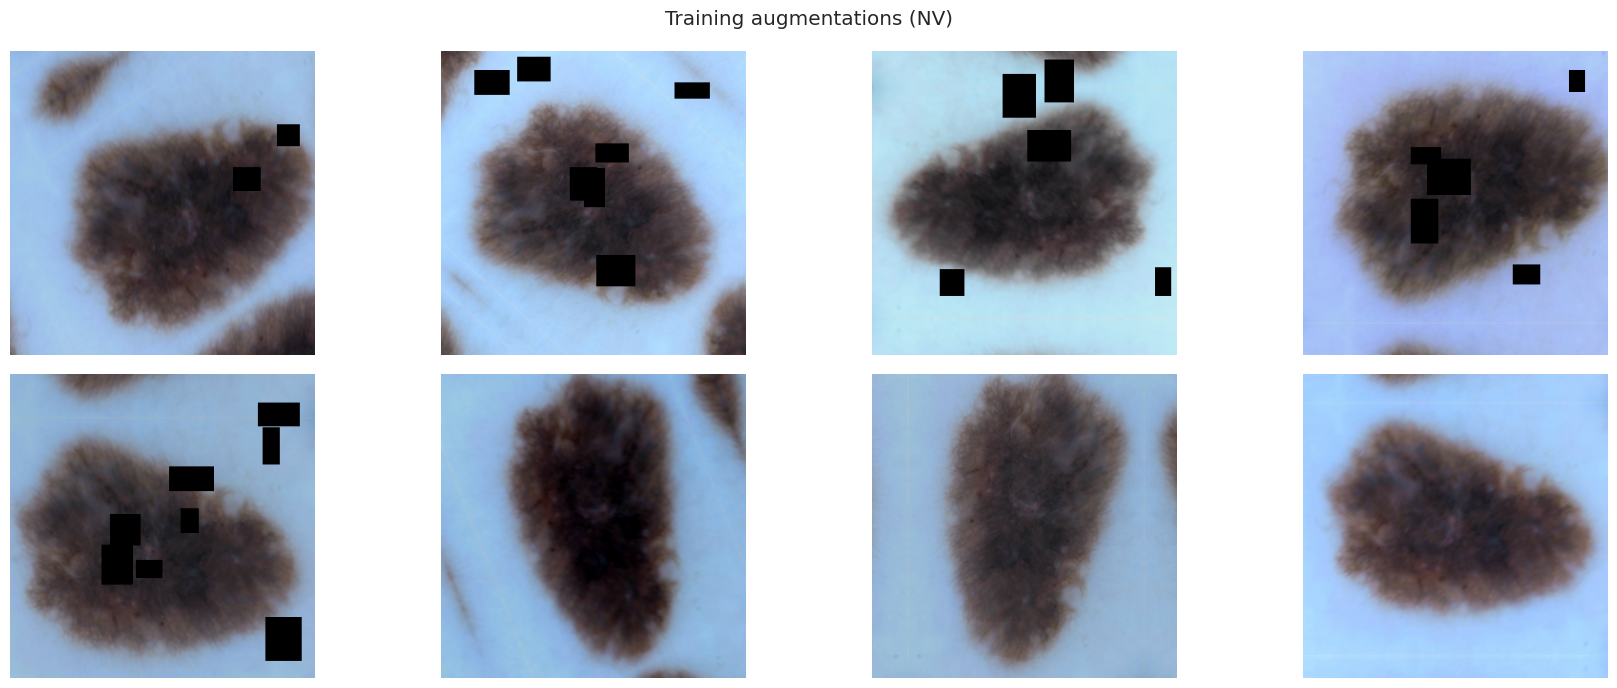

In [12]:
class ISICDataset(Dataset):
    """Returns (image_tensor, label). Image decoding is done with OpenCV for speed."""

    def __init__(self, frame: pd.DataFrame, transforms: Optional[A.Compose] = None) -> None:
        self.paths = frame["image_path"].tolist()
        self.labels = frame["label"].astype(np.int64).tolist()
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        path = self.paths[index]
        image = cv2.imread(path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Unreadable image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            image = self.transforms(image=image)["image"]

        return image, self.labels[index]


def visualize_augmentations(frame: pd.DataFrame, n: int = 8) -> None:
    """Eyeball the augmentation strength before committing GPU hours to it."""
    transforms = get_train_transforms(CFG.image_size)
    image = cv2.cvtColor(cv2.imread(frame.loc[0, "image_path"]), cv2.COLOR_BGR2RGB)
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    fig, axes = plt.subplots(2, n // 2, figsize=(18, 7))
    for ax in axes.ravel():
        tensor = transforms(image=image)["image"]
        shown = np.clip(tensor.permute(1, 2, 0).numpy() * std + mean, 0, 1)
        ax.imshow(shown)
        ax.axis("off")
    fig.suptitle(f"Training augmentations ({frame.loc[0, 'label_str']})")
    plt.tight_layout()
    plt.show()


visualize_augmentations(df_data)

## 7. Soft targets, MixUp, CutMix, and Focal Loss

Key correctness detail: MixUp/CutMix produce **soft** targets, so the loss must accept a probability
matrix, not integer classes. Interpolating two hard-target losses (the common shortcut) is wrong once
label smoothing is involved. Here everything flows through one soft-target focal loss.

In [13]:
def to_soft_targets(
    targets: torch.Tensor, num_classes: int, smoothing: float = 0.0
) -> torch.Tensor:
    """One-hot encode with optional label smoothing -> (B, C) float tensor."""
    off_value = smoothing / num_classes
    on_value = 1.0 - smoothing + off_value
    soft = torch.full(
        (targets.size(0), num_classes), off_value, device=targets.device, dtype=torch.float32
    )
    return soft.scatter_(1, targets.long().view(-1, 1), on_value)


def mixup(
    images: torch.Tensor, soft_targets: torch.Tensor, alpha: float
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Convex combination of images and their soft targets."""
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[perm]
    return mixed, lam * soft_targets + (1.0 - lam) * soft_targets[perm]


def cutmix(
    images: torch.Tensor, soft_targets: torch.Tensor, alpha: float
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Paste a random patch from a shuffled batch; mix targets by the true pasted area."""
    lam = float(np.random.beta(alpha, alpha))
    batch, _, height, width = images.shape
    perm = torch.randperm(batch, device=images.device)

    cut_ratio = math.sqrt(1.0 - lam)
    cut_h, cut_w = int(height * cut_ratio), int(width * cut_ratio)
    center_y, center_x = np.random.randint(height), np.random.randint(width)

    y1, y2 = np.clip([center_y - cut_h // 2, center_y + cut_h // 2], 0, height)
    x1, x2 = np.clip([center_x - cut_w // 2, center_x + cut_w // 2], 0, width)

    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]

    # Recompute lambda from the actual box so clipping cannot desync image and target.
    true_lam = 1.0 - ((y2 - y1) * (x2 - x1) / (height * width))
    return mixed, true_lam * soft_targets + (1.0 - true_lam) * soft_targets[perm]


def apply_batch_mixing(
    images: torch.Tensor, soft_targets: torch.Tensor, config: Config
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Randomly apply MixUp or CutMix (or neither) to a batch."""
    if np.random.rand() >= config.mix_prob:
        return images, soft_targets
    if np.random.rand() < 0.5 and config.mixup_alpha > 0:
        return mixup(images, soft_targets, config.mixup_alpha)
    if config.cutmix_alpha > 0:
        return cutmix(images, soft_targets, config.cutmix_alpha)
    return images, soft_targets

In [14]:
def compute_class_weights(labels: np.ndarray, num_classes: int, power: float) -> torch.Tensor:
    """Inverse-frequency weights raised to `power`, normalized to mean 1.

    power=0 -> uniform, 0.5 -> sqrt-inverse (recommended with focal loss), 1.0 -> full inverse.
    Full inverse plus focal loss usually over-corrects and wrecks NV precision.
    """
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = (counts.sum() / (num_classes * counts)) ** power
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


class SoftTargetFocalLoss(nn.Module):
    """Multi-class focal loss that accepts soft targets and per-class alpha weights."""

    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0) -> None:
        super().__init__()
        self.gamma = gamma
        self.register_buffer(
            "alpha", alpha if alpha is not None else torch.ones(NUM_CLASSES), persistent=False
        )

    def forward(self, logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits.float(), dim=1)
        probs = log_probs.exp()
        focal_log_probs = ((1.0 - probs) ** self.gamma) * log_probs
        weighted = focal_log_probs * self.alpha.to(logits.device).view(1, -1)
        return -(soft_targets * weighted).sum(dim=1).mean()


# Sanity check: a confident correct prediction must cost far less than a confident wrong one.
_loss_fn = SoftTargetFocalLoss(gamma=2.0)
_good = _loss_fn(torch.tensor([[8.0, 0.0, 0.0, 0, 0, 0, 0, 0]]), to_soft_targets(torch.tensor([0]), 8))
_bad = _loss_fn(torch.tensor([[8.0, 0.0, 0.0, 0, 0, 0, 0, 0]]), to_soft_targets(torch.tensor([3]), 8))
print(f"focal loss - correct: {_good.item():.5f} | wrong: {_bad.item():.5f}")
assert _good < _bad

focal loss - correct: 0.00000 | wrong: 7.99699


## 8. ConvNeXt model, layer groups, progressive unfreezing, EMA

Layer group ids: `0` = stem, `1..4` = ConvNeXt stages, `99` = head. Those ids drive **both** the
layer-wise LR decay and the unfreeze schedule, so the two never disagree.

In [15]:
class SkinLesionClassifier(nn.Module):
    """timm backbone (pooled features) + a custom normalized classification head."""

    def __init__(
        self,
        model_name: str,
        num_classes: int,
        pretrained: bool = True,
        drop_path_rate: float = 0.2,
        head_dropout: float = 0.3,
    ) -> None:
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,               # strip the original classifier, keep global pooling
            drop_path_rate=drop_path_rate,
        )
        num_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(head_dropout),
            nn.Linear(num_features, num_classes),
        )
        nn.init.trunc_normal_(self.head[-1].weight, std=0.01)
        nn.init.zeros_(self.head[-1].bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.backbone(x))


def layer_group_id(param_name: str) -> int:
    """Map a parameter name to a depth group. Works for ConvNeXt and EfficientNet naming."""
    if param_name.startswith("head"):
        return 99
    if "stem" in param_name or "conv_stem" in param_name or "bn1" in param_name:
        return 0
    match = re.search(r"(?:stages|blocks|layers)\.(\d+)", param_name)
    if match:
        return int(match.group(1)) + 1
    return 99  # final norms and anything unmatched trains with the head


def build_param_groups(model: nn.Module, config: Config) -> List[Dict]:
    """Layer-wise LR decay + no weight decay on norms and biases."""
    groups: Dict[Tuple[int, bool], Dict] = {}
    backbone_ids = [
        layer_group_id(name) for name, _ in model.named_parameters() if layer_group_id(name) != 99
    ]
    depth = max(backbone_ids) if backbone_ids else 0

    for name, param in model.named_parameters():
        group_id = layer_group_id(name)
        decay = param.ndim > 1 and not name.endswith(".bias")
        key = (group_id, decay)
        if key not in groups:
            if group_id == 99:
                scale = 1.0
            else:
                # deeper layers get LRs closer to the head, early layers get much smaller ones
                scale = config.layer_decay ** (depth + 1 - group_id)
            groups[key] = {
                "params": [],
                "lr": config.base_lr * scale,
                "initial_lr": config.base_lr * scale,
                "weight_decay": config.weight_decay if decay else 0.0,
                "group_id": group_id,
            }
        groups[key]["params"].append(param)

    ordered = [groups[key] for key in sorted(groups)]
    print(
        "Param groups:",
        [(g["group_id"], f"lr={g['lr']:.2e}", f"wd={g['weight_decay']}", len(g["params"])) for g in ordered],
    )
    return ordered


def set_trainable_from(model: nn.Module, min_group_id: int) -> int:
    """Freeze everything shallower than `min_group_id`. Returns trainable param count."""
    for name, param in model.named_parameters():
        param.requires_grad = layer_group_id(name) >= min_group_id
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class ModelEMA:
    """Exponential moving average of weights. Almost always beats the raw model at eval time."""

    def __init__(self, model: nn.Module, decay: float = 0.9995) -> None:
        self.module = deepcopy(model).eval()
        self.decay = decay
        for param in self.module.parameters():
            param.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        for ema_v, model_v in zip(self.module.state_dict().values(), model.state_dict().values()):
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(model_v.detach(), alpha=1.0 - self.decay)
            else:
                ema_v.copy_(model_v)


_probe_model = SkinLesionClassifier(CFG.model_name, NUM_CLASSES, pretrained=False)
with torch.no_grad():
    _out = _probe_model(torch.randn(2, 3, CFG.image_size, CFG.image_size))
print("forward shape:", tuple(_out.shape), "(expected (2, 8))")
assert _out.shape == (2, NUM_CLASSES)
del _probe_model, _out
gc.collect()

forward shape: (2, 8) (expected (2, 8))


11964

## 9. AMP wrapper, metrics, early stopping

`torch.cuda.amp` is deprecated in torch 2.4+ but `torch.amp` does not exist before 1.10. This wrapper
picks whichever is available so the same notebook runs on either.

In [16]:
AMP_DEVICE_TYPE = "cuda" if DEVICE.type == "cuda" else "cpu"


def make_grad_scaler(enabled: bool):
    """GradScaler across torch versions."""
    try:
        return torch.amp.GradScaler(AMP_DEVICE_TYPE, enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_ctx(enabled: bool):
    """autocast across torch versions."""
    try:
        return torch.amp.autocast(AMP_DEVICE_TYPE, enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=enabled)


AMP_ENABLED = CFG.mixed_precision and DEVICE.type == "cuda"
print("AMP enabled:", AMP_ENABLED)


def compute_metrics(
    y_true: np.ndarray, y_prob: np.ndarray, class_names: Sequence[str]
) -> Dict[str, float]:
    """Accuracy, macro/weighted F1, balanced accuracy, kappa, macro OVR AUC."""
    y_pred = y_prob.argmax(axis=1)
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "kappa": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
    }
    try:
        binarized = label_binarize(y_true, classes=np.arange(len(class_names)))
        metrics["macro_auc"] = float(
            roc_auc_score(binarized, y_prob, average="macro", multi_class="ovr")
        )
    except ValueError:
        metrics["macro_auc"] = float("nan")
    return metrics


class EarlyStopping:
    """Patience-based stop on a maximized metric."""

    def __init__(self, patience: int = 5, min_delta: float = 1e-4) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best: Optional[float] = None
        self.counter = 0

    def __call__(self, score: float) -> bool:
        if self.best is None or score > self.best + self.min_delta:
            self.best = score
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

AMP enabled: True


## 10. Test-Time Augmentation

Dermoscopy has no canonical orientation, so the full dihedral group (4 rotations x 2 flips) is free
accuracy. TTA runs on GPU tensors, so there is no extra image decoding cost.

In [17]:
def dihedral(x: torch.Tensor, index: int) -> torch.Tensor:
    """Apply one of 8 symmetry transforms to a NCHW batch."""
    rotated = torch.rot90(x, index % 4, dims=(2, 3))
    return torch.flip(rotated, dims=(3,)) if index >= 4 else rotated


@torch.no_grad()
def predict_probs(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    use_tta: bool = True,
    tta_transforms: int = 8,
    channels_last: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities, labels), averaging softmax over TTA views."""
    model.eval()
    all_probs, all_labels = [], []
    views = max(1, min(tta_transforms, 8)) if use_tta else 1

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        if channels_last and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        accumulated = torch.zeros(images.size(0), NUM_CLASSES, device=device, dtype=torch.float32)
        for view in range(views):
            with autocast_ctx(AMP_ENABLED):
                logits = model(dihedral(images, view))
            accumulated += torch.softmax(logits.float(), dim=1)

        all_probs.append((accumulated / views).cpu().numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)

## 11. Train / validate loops

In [18]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[CosineAnnealingWarmRestarts],
    criterion: nn.Module,
    scaler,
    device: torch.device,
    epoch: int,
    config: Config,
    ema: Optional[ModelEMA] = None,
) -> float:
    """One training epoch. Returns mean loss.

    `epoch` is passed explicitly so the cosine schedule advances per iteration
    without relying on any global state.
    """
    model.train()
    steps = max(len(loader), 1)
    running_loss, seen = 0.0, 0

    for step, (images, targets) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if config.channels_last and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        soft_targets = to_soft_targets(targets, NUM_CLASSES, config.label_smoothing)
        images, soft_targets = apply_batch_mixing(images, soft_targets, config)

        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx(AMP_ENABLED):
            loss = criterion(model(images), soft_targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                        # unscale before clipping, never after
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], config.max_grad_norm
        )
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)
        if scheduler is not None:
            scheduler.step(epoch + step / steps)

        running_loss += loss.item() * images.size(0)
        seen += images.size(0)

        if step % max(steps // 5, 1) == 0:
            print(
                f"  step {step:>4}/{steps} loss {running_loss / max(seen, 1):.4f} "
                f"lr {optimizer.param_groups[-1]['lr']:.2e}"
            )

    return running_loss / max(seen, 1)


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    config: Config,
    use_tta: bool = False,
) -> Tuple[Dict[str, float], np.ndarray, np.ndarray]:
    """Validate with hard targets. TTA is off during training epochs to keep them fast."""
    model.eval()
    running_loss, seen = 0.0, 0
    all_probs, all_labels = [], []
    views = config.tta_transforms if use_tta else 1

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        targets = labels.to(device, non_blocking=True)
        if config.channels_last and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        accumulated = torch.zeros(images.size(0), NUM_CLASSES, device=device, dtype=torch.float32)
        for view in range(views):
            with autocast_ctx(AMP_ENABLED):
                logits = model(dihedral(images, view))
                if view == 0:
                    loss = criterion(logits, to_soft_targets(targets, NUM_CLASSES, 0.0))
            accumulated += torch.softmax(logits.float(), dim=1)

        running_loss += loss.item() * images.size(0)
        seen += images.size(0)
        all_probs.append((accumulated / views).cpu().numpy())
        all_labels.append(labels.numpy())

    probs = np.concatenate(all_probs)
    labels_np = np.concatenate(all_labels)
    metrics = compute_metrics(labels_np, probs, TARGET_CLASSES)
    metrics["loss"] = running_loss / max(seen, 1)
    return metrics, probs, labels_np

## 12. DataLoaders

In [19]:
def build_dataloaders(
    frame: pd.DataFrame, fold: int, config: Config
) -> Tuple[DataLoader, DataLoader, pd.DataFrame, pd.DataFrame]:
    """Train/valid loaders for one fold, with an optional balanced sampler."""
    train_df = frame[frame["fold"] != fold].reset_index(drop=True)
    valid_df = frame[frame["fold"] == fold].reset_index(drop=True)

    train_ds = ISICDataset(train_df, get_train_transforms(config.image_size))
    valid_ds = ISICDataset(valid_df, get_valid_transforms(config.image_size))

    sampler = None
    if config.use_weighted_sampler:
        counts = train_df["label"].value_counts().reindex(range(NUM_CLASSES)).fillna(0).values
        # sqrt-inverse sampling: rebalances without letting 200 DF images dominate every epoch
        per_class = 1.0 / np.sqrt(np.maximum(counts, 1.0))
        sample_weights = train_df["label"].map(dict(enumerate(per_class))).values
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(train_df),
            replacement=True,
        )

    common = dict(
        num_workers=config.num_workers,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=config.num_workers > 0,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=config.batch_size,
        shuffle=sampler is None,
        sampler=sampler,
        drop_last=True,                 # keeps MixUp/BatchNorm stable on the last partial batch
        **common,
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=config.val_batch_size, shuffle=False, drop_last=False, **common
    )

    print(f"fold {fold}: train {len(train_ds):,} | valid {len(valid_ds):,}")
    return train_loader, valid_loader, train_df, valid_df

## 13. Fold training with progressive unfreezing

The optimizer is built **once** over all parameter groups. Unfreezing flips `requires_grad`, which
means AdamW momentum for already-trained layers is never thrown away mid-run.

In [20]:
def train_fold(frame: pd.DataFrame, fold: int, config: Config) -> Dict:
    """Train one fold and return checkpoint path, history, and OOF predictions."""
    seed_everything(SEED + fold)
    train_loader, valid_loader, train_df, valid_df = build_dataloaders(frame, fold, config)

    model = SkinLesionClassifier(
        config.model_name,
        NUM_CLASSES,
        pretrained=config.pretrained,
        drop_path_rate=config.drop_path_rate,
        head_dropout=config.head_dropout,
    ).to(DEVICE)
    if config.channels_last and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)

    class_weights = compute_class_weights(
        train_df["label"].values, NUM_CLASSES, config.class_weight_power
    )
    print("class weights:", dict(zip(TARGET_CLASSES, np.round(class_weights.numpy(), 3))))
    criterion = SoftTargetFocalLoss(alpha=class_weights, gamma=config.focal_gamma).to(DEVICE)

    optimizer = AdamW(build_param_groups(model, config), betas=(0.9, 0.999))
    scheduler = CosineAnnealingWarmRestarts(
        optimizer, T_0=config.scheduler_t0, T_mult=config.scheduler_tmult, eta_min=config.min_lr
    )
    scaler = make_grad_scaler(AMP_ENABLED)
    ema = ModelEMA(model, config.ema_decay) if config.use_ema else None
    stopper = EarlyStopping(config.early_stopping_patience)

    checkpoint_path = config.checkpoint_dir / f"{config.model_name.split('.')[0]}_fold{fold}.pth"
    history: List[Dict] = []
    best_score, best_probs, best_source = -np.inf, None, "raw"

    for epoch in range(config.epochs):
        if epoch in config.unfreeze_schedule:
            trainable = set_trainable_from(model, config.unfreeze_schedule[epoch])
            print(
                f"\n[fold {fold}] epoch {epoch + 1}: unfreezing from group "
                f"{config.unfreeze_schedule[epoch]} -> {trainable:,} trainable params"
            )

        print(f"[fold {fold}] epoch {epoch + 1}/{config.epochs}")
        train_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, scaler, DEVICE, epoch, config, ema
        )

        raw_metrics, raw_probs, y_true = validate(model, valid_loader, criterion, DEVICE, config)
        candidates = [("raw", raw_metrics, raw_probs)]

        if ema is not None:
            ema_metrics, ema_probs, _ = validate(ema.module, valid_loader, criterion, DEVICE, config)
            candidates.append(("ema", ema_metrics, ema_probs))

        source, metrics, probs = max(candidates, key=lambda item: item[1]["macro_f1"])
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "source": source, **metrics})

        print(
            f"[fold {fold}] epoch {epoch + 1}: train {train_loss:.4f} | val {metrics['loss']:.4f} "
            f"| acc {metrics['accuracy']:.4f} | macroF1 {metrics['macro_f1']:.4f} "
            f"| wF1 {metrics['weighted_f1']:.4f} | AUC {metrics['macro_auc']:.4f} ({source})"
        )

        if metrics["macro_f1"] > best_score:
            best_score, best_probs, best_source = metrics["macro_f1"], probs, source
            state = (ema.module if source == "ema" else model).state_dict()
            torch.save(
                {
                    "state_dict": state,
                    "config": {"model_name": config.model_name, "image_size": config.image_size},
                    "fold": fold,
                    "macro_f1": best_score,
                    "source": source,
                },
                checkpoint_path,
            )
            print(f"  saved new best ({source}) macro F1 {best_score:.4f}")

        if stopper(metrics["macro_f1"]):
            print(f"[fold {fold}] early stopping at epoch {epoch + 1}")
            break

    del model, ema, optimizer, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "fold": fold,
        "checkpoint": checkpoint_path,
        "history": pd.DataFrame(history),
        "best_macro_f1": best_score,
        "best_source": best_source,
        "oof_probs": best_probs,
        "oof_labels": y_true,
        "valid_index": valid_df.index.values,
        "valid_df": valid_df,
    }

## 14. Run training

Set `folds_to_run` to `(0, 1, 2, 3, 4)` for the full 5-fold ensemble. Single fold first: verify the
loop end to end, then spend the GPU hours.

In [21]:
fold_results = [train_fold(df_data, fold, CFG) for fold in CFG.folds_to_run]

summary = pd.DataFrame(
    [
        {
            "fold": result["fold"],
            "best_macro_f1": result["best_macro_f1"],
            "weights": result["best_source"],
            "checkpoint": result["checkpoint"].name,
        }
        for result in fold_results
    ]
)
display(summary)

fold 0: train 20,264 | valid 5,067


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

class weights: {'MEL': np.float32(0.454), 'NV': np.float32(0.269), 'BCC': np.float32(0.53), 'AK': np.float32(1.038), 'BKL': np.float32(0.597), 'DF': np.float32(1.973), 'VASC': np.float32(1.918), 'SCC': np.float32(1.22)}
Param groups: [(0, 'lr=7.12e-05', 'wd=0.0', 3), (0, 'lr=7.12e-05', 'wd=0.05', 1), (1, 'lr=9.49e-05', 'wd=0.0', 18), (1, 'lr=9.49e-05', 'wd=0.05', 9), (2, 'lr=1.27e-04', 'wd=0.0', 21), (2, 'lr=1.27e-04', 'wd=0.05', 10), (3, 'lr=1.69e-04', 'wd=0.0', 165), (3, 'lr=1.69e-04', 'wd=0.05', 82), (4, 'lr=2.25e-04', 'wd=0.0', 21), (4, 'lr=2.25e-04', 'wd=0.05', 10), (99, 'lr=3.00e-04', 'wd=0.0', 5), (99, 'lr=3.00e-04', 'wd=0.05', 1)]

[fold 0] epoch 1: unfreezing from group 99 -> 12,296 trainable params
[fold 0] epoch 1/15
  step    0/1266 loss 0.8171 lr 3.00e-04
  step  253/1266 loss 0.9216 lr 2.99e-04
  step  506/1266 loss 0.8709 lr 2.95e-04
  step  759/1266 loss 0.8453 lr 2.90e-04
  step 1012/1266 loss 0.8324 lr 2.82e-04
  step 1265/1266 loss 0.8218 lr 2.71e-04
[fold 0] epoch 1

,fold,best_macro_f1,weights,checkpoint
0,0,0.84458,raw,convnext_base_fold0.pth


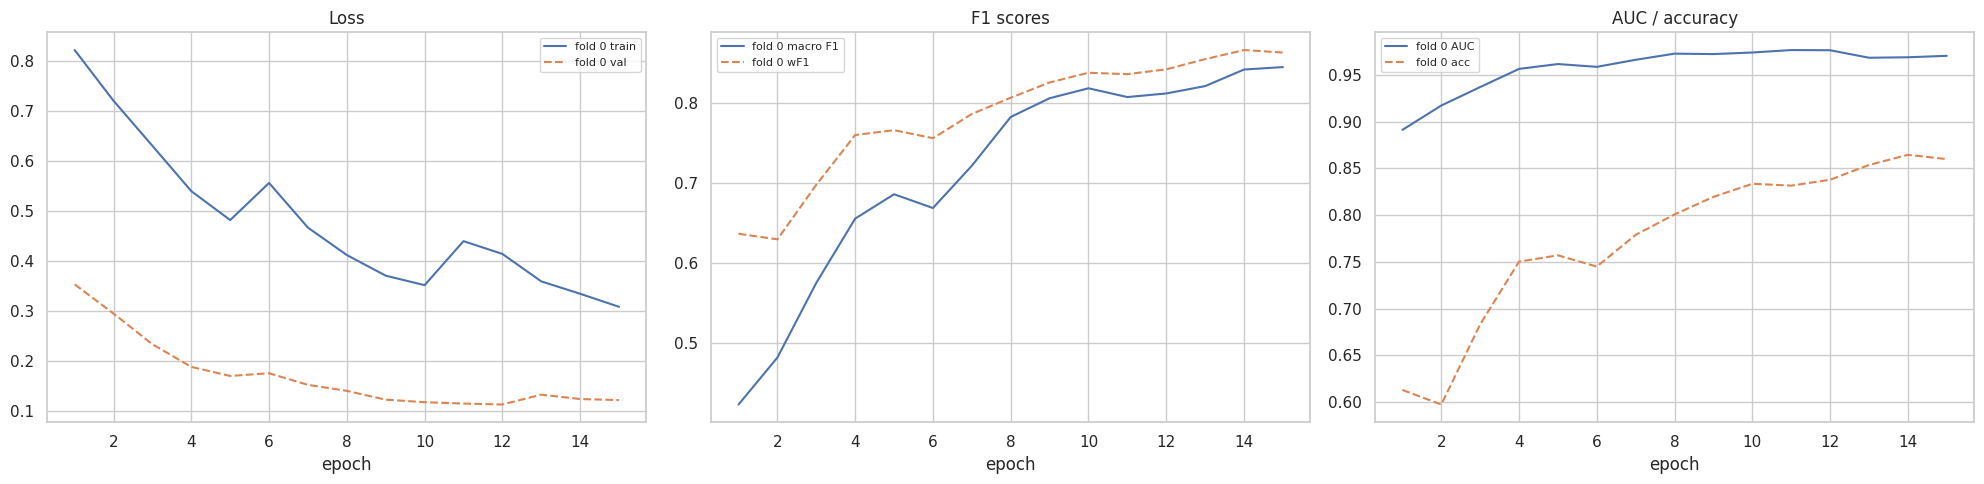

In [22]:
def plot_history(results: List[Dict]) -> None:
    """Loss, F1, and AUC curves per fold."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for result in results:
        history = result["history"]
        label = f"fold {result['fold']}"
        axes[0].plot(history["epoch"], history["train_loss"], label=f"{label} train")
        axes[0].plot(history["epoch"], history["loss"], linestyle="--", label=f"{label} val")
        axes[1].plot(history["epoch"], history["macro_f1"], label=f"{label} macro F1")
        axes[1].plot(history["epoch"], history["weighted_f1"], linestyle="--", label=f"{label} wF1")
        axes[2].plot(history["epoch"], history["macro_auc"], label=f"{label} AUC")
        axes[2].plot(history["epoch"], history["accuracy"], linestyle="--", label=f"{label} acc")

    for ax, title in zip(axes, ["Loss", "F1 scores", "AUC / accuracy"]):
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_history(fold_results)

## 15. Out-of-fold evaluation with TTA

We reload each best checkpoint and re-predict its validation fold **with 8x TTA**, then stitch the
folds into a single OOF matrix. This is the number worth quoting: every prediction comes from a model
that never saw that image.

In [23]:
def load_checkpoint(path: Path, config: Config) -> nn.Module:
    """Rebuild the architecture and load saved weights (no pretrained download needed)."""
    payload = torch.load(path, map_location="cpu", weights_only=False)
    model = SkinLesionClassifier(
        payload["config"]["model_name"],
        NUM_CLASSES,
        pretrained=False,
        drop_path_rate=0.0,
        head_dropout=0.0,
    )
    model.load_state_dict(payload["state_dict"])
    model.to(DEVICE).eval()
    if config.channels_last and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    return model


oof_probs = np.zeros((len(df_data), NUM_CLASSES), dtype=np.float32)
oof_mask = np.zeros(len(df_data), dtype=bool)

for result in fold_results:
    fold = result["fold"]
    valid_df = df_data[df_data["fold"] == fold]
    loader = DataLoader(
        ISICDataset(valid_df, get_valid_transforms(CFG.image_size)),
        batch_size=CFG.val_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=DEVICE.type == "cuda",
    )

    model = load_checkpoint(result["checkpoint"], CFG)
    probs, _ = predict_probs(
        model, loader, DEVICE, CFG.use_tta, CFG.tta_transforms, CFG.channels_last
    )
    oof_probs[valid_df.index.values] = probs
    oof_mask[valid_df.index.values] = True

    fold_metrics = compute_metrics(valid_df["label"].values, probs, TARGET_CLASSES)
    print(f"fold {fold} with TTA:", {k: round(v, 4) for k, v in fold_metrics.items()})

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

y_true = df_data.loc[oof_mask, "label"].values
y_prob = oof_probs[oof_mask]
y_pred = y_prob.argmax(axis=1)

print(f"\nOOF coverage: {oof_mask.sum():,} / {len(df_data):,} images")
oof_metrics = compute_metrics(y_true, y_prob, TARGET_CLASSES)
display(pd.Series(oof_metrics).round(4).to_frame("OOF (TTA)"))

fold 0 with TTA: {'accuracy': 0.8642, 'balanced_accuracy': 0.8562, 'macro_f1': 0.8446, 'weighted_f1': 0.8667, 'kappa': 0.8512, 'macro_auc': 0.9744}

OOF coverage: 5,067 / 25,331 images


,OOF (TTA)
accuracy,0.8642
balanced_accuracy,0.8562
macro_f1,0.8446
weighted_f1,0.8667
kappa,0.8512
macro_auc,0.9744


In [24]:
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4, zero_division=0))

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)
per_class = pd.DataFrame(
    {"support": support, "precision": precision, "recall": recall, "f1": f1_per_class},
    index=TARGET_CLASSES,
).sort_values("f1")
display(per_class.round(4))
print("Weakest classes drive macro F1. That is where extra data or oversampling pays off.")

              precision    recall  f1-score   support

         MEL     0.7140    0.8331    0.7690       905
          NV     0.9471    0.8687    0.9062      2575
         BCC     0.8967    0.9263    0.9112       665
          AK     0.7120    0.7816    0.7452       174
         BKL     0.8134    0.8552    0.8338       525
          DF     0.8696    0.8511    0.8602        47
        VASC     0.9038    0.9400    0.9216        50
         SCC     0.8264    0.7937    0.8097       126

    accuracy                         0.8642      5067
   macro avg     0.8354    0.8562    0.8446      5067
weighted avg     0.8728    0.8642    0.8667      5067



,support,precision,recall,f1
AK,174,0.7120,0.7816,0.7452
MEL,905,0.7140,0.8331,0.7690
SCC,126,0.8264,0.7937,0.8097
BKL,525,0.8134,0.8552,0.8338
DF,47,0.8696,0.8511,0.8602
NV,2575,0.9471,0.8687,0.9062
BCC,665,0.8967,0.9263,0.9112
VASC,50,0.9038,0.9400,0.9216


Weakest classes drive macro F1. That is where extra data or oversampling pays off.


## 16. Confusion matrices

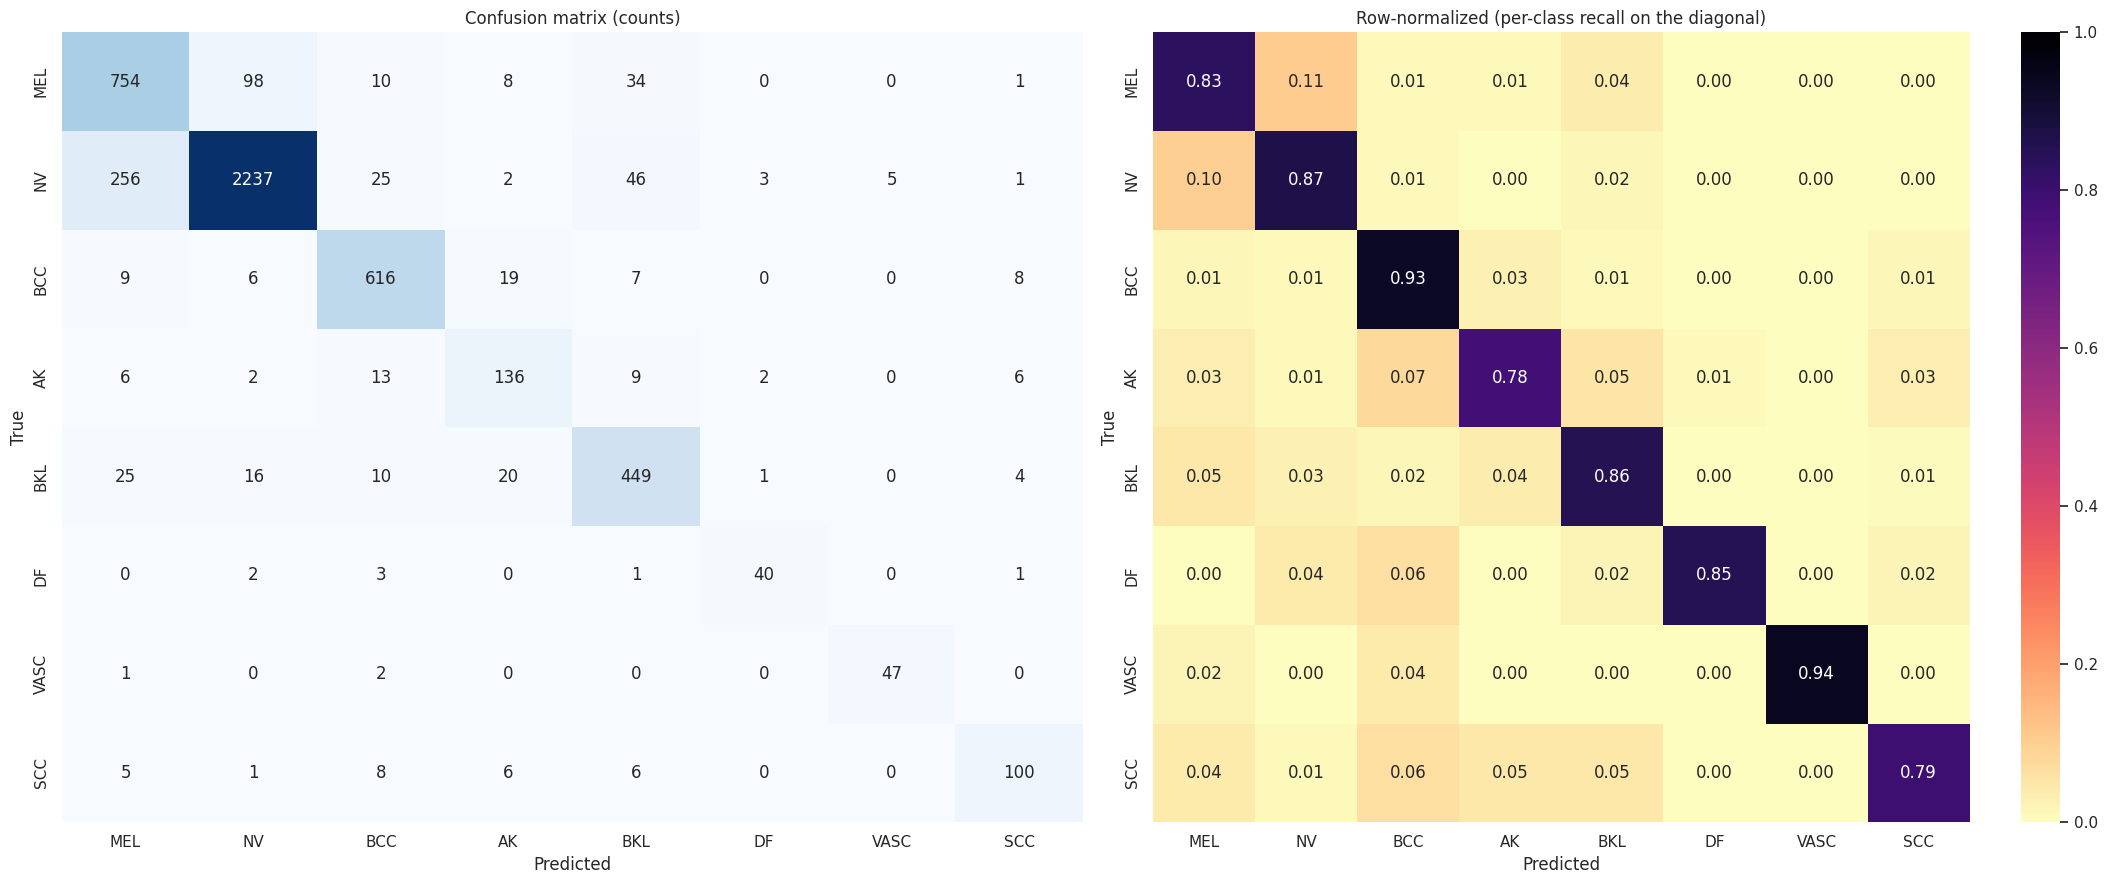

In [25]:
def plot_confusion_matrices(
    y_true: np.ndarray, y_pred: np.ndarray, class_names: Sequence[str]
) -> None:
    """Raw counts next to row-normalized recall, which is what actually matters clinically."""
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    normalized = np.nan_to_num(matrix / matrix.sum(axis=1, keepdims=True))

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_title("Confusion matrix (counts)")

    sns.heatmap(
        normalized,
        annot=True,
        fmt=".2f",
        cmap="magma_r",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
    )
    axes[1].set_title("Row-normalized (per-class recall on the diagonal)")

    for ax in axes:
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(y_true, y_pred, TARGET_CLASSES)

## 17. Multi-class ROC-AUC

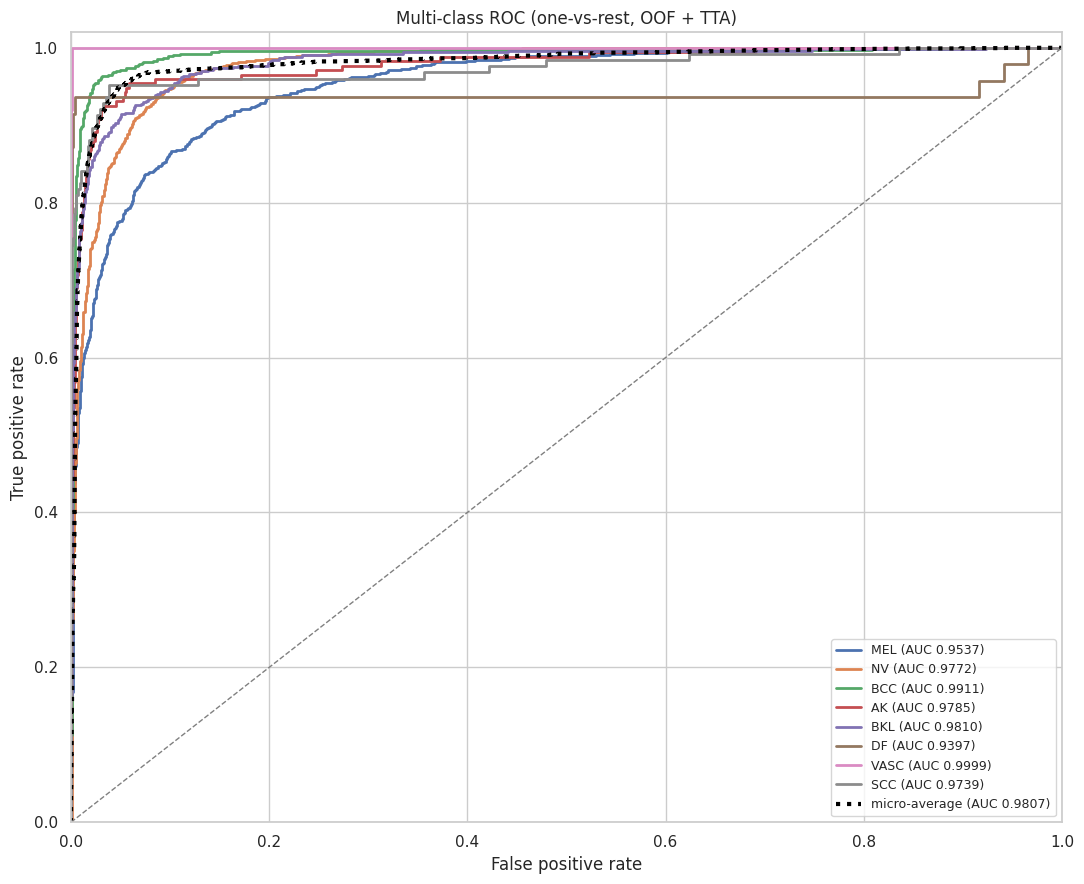

Macro AUC: 0.9744
Micro AUC: 0.9807


,auc,support
class,,
MEL,0.9537,905
NV,0.9772,2575
BCC,0.9911,665
AK,0.9785,174
BKL,0.9810,525
DF,0.9397,47
VASC,0.9999,50
SCC,0.9739,126


In [26]:
def plot_multiclass_roc(
    y_true: np.ndarray, y_prob: np.ndarray, class_names: Sequence[str]
) -> pd.DataFrame:
    """One-vs-rest ROC curves plus micro/macro averages."""
    binarized = label_binarize(y_true, classes=np.arange(len(class_names)))
    rows = []

    plt.figure(figsize=(11, 9))
    for index, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(binarized[:, index], y_prob[:, index])
        area = auc(fpr, tpr)
        rows.append({"class": name, "auc": area, "support": int(binarized[:, index].sum())})
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC {area:.4f})")

    micro_fpr, micro_tpr, _ = roc_curve(binarized.ravel(), y_prob.ravel())
    plt.plot(
        micro_fpr,
        micro_tpr,
        lw=3,
        linestyle=":",
        color="black",
        label=f"micro-average (AUC {auc(micro_fpr, micro_tpr):.4f})",
    )
    plt.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Multi-class ROC (one-vs-rest, OOF + TTA)")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(rows).set_index("class")
    print(f"Macro AUC: {table['auc'].mean():.4f}")
    print(f"Micro AUC: {auc(micro_fpr, micro_tpr):.4f}")
    return table


auc_table = plot_multiclass_roc(y_true, y_prob, TARGET_CLASSES)
display(auc_table.round(4))

## 18. Per-class logit adjustment (free macro-F1)

`argmax` on raw probabilities optimizes accuracy, not macro F1. Tuning one multiplicative prior per
class via coordinate ascent on OOF predictions typically buys **2-5 macro-F1 points at zero training
cost**. Fit on OOF only, then reuse the same vector at inference.

,argmax,prior-adjusted
accuracy,0.8642,0.8838
balanced_accuracy,0.8562,0.8633
macro_f1,0.8446,0.8636
weighted_f1,0.8667,0.8835
kappa,0.8512,0.8649
macro_auc,0.9744,0.9744


tuned log-priors: {'MEL': np.float64(-0.3), 'NV': np.float64(0.3), 'BCC': np.float64(-0.4), 'AK': np.float64(-0.1), 'BKL': np.float64(0.0), 'DF': np.float64(-0.5), 'VASC': np.float64(0.2), 'SCC': np.float64(-1.0)}

Classification report after prior adjustment:
              precision    recall  f1-score   support

         MEL     0.8102    0.7691    0.7891       905
          NV     0.9248    0.9266    0.9257      2575
         BCC     0.9152    0.9248    0.9200       665
          AK     0.7282    0.8161    0.7696       174
         BKL     0.8093    0.8648    0.8361       525
          DF     0.9091    0.8511    0.8791        47
        VASC     0.9091    1.0000    0.9524        50
         SCC     0.9406    0.7540    0.8370       126

    accuracy                         0.8838      5067
   macro avg     0.8683    0.8633    0.8636      5067
weighted avg     0.8845    0.8838    0.8835      5067



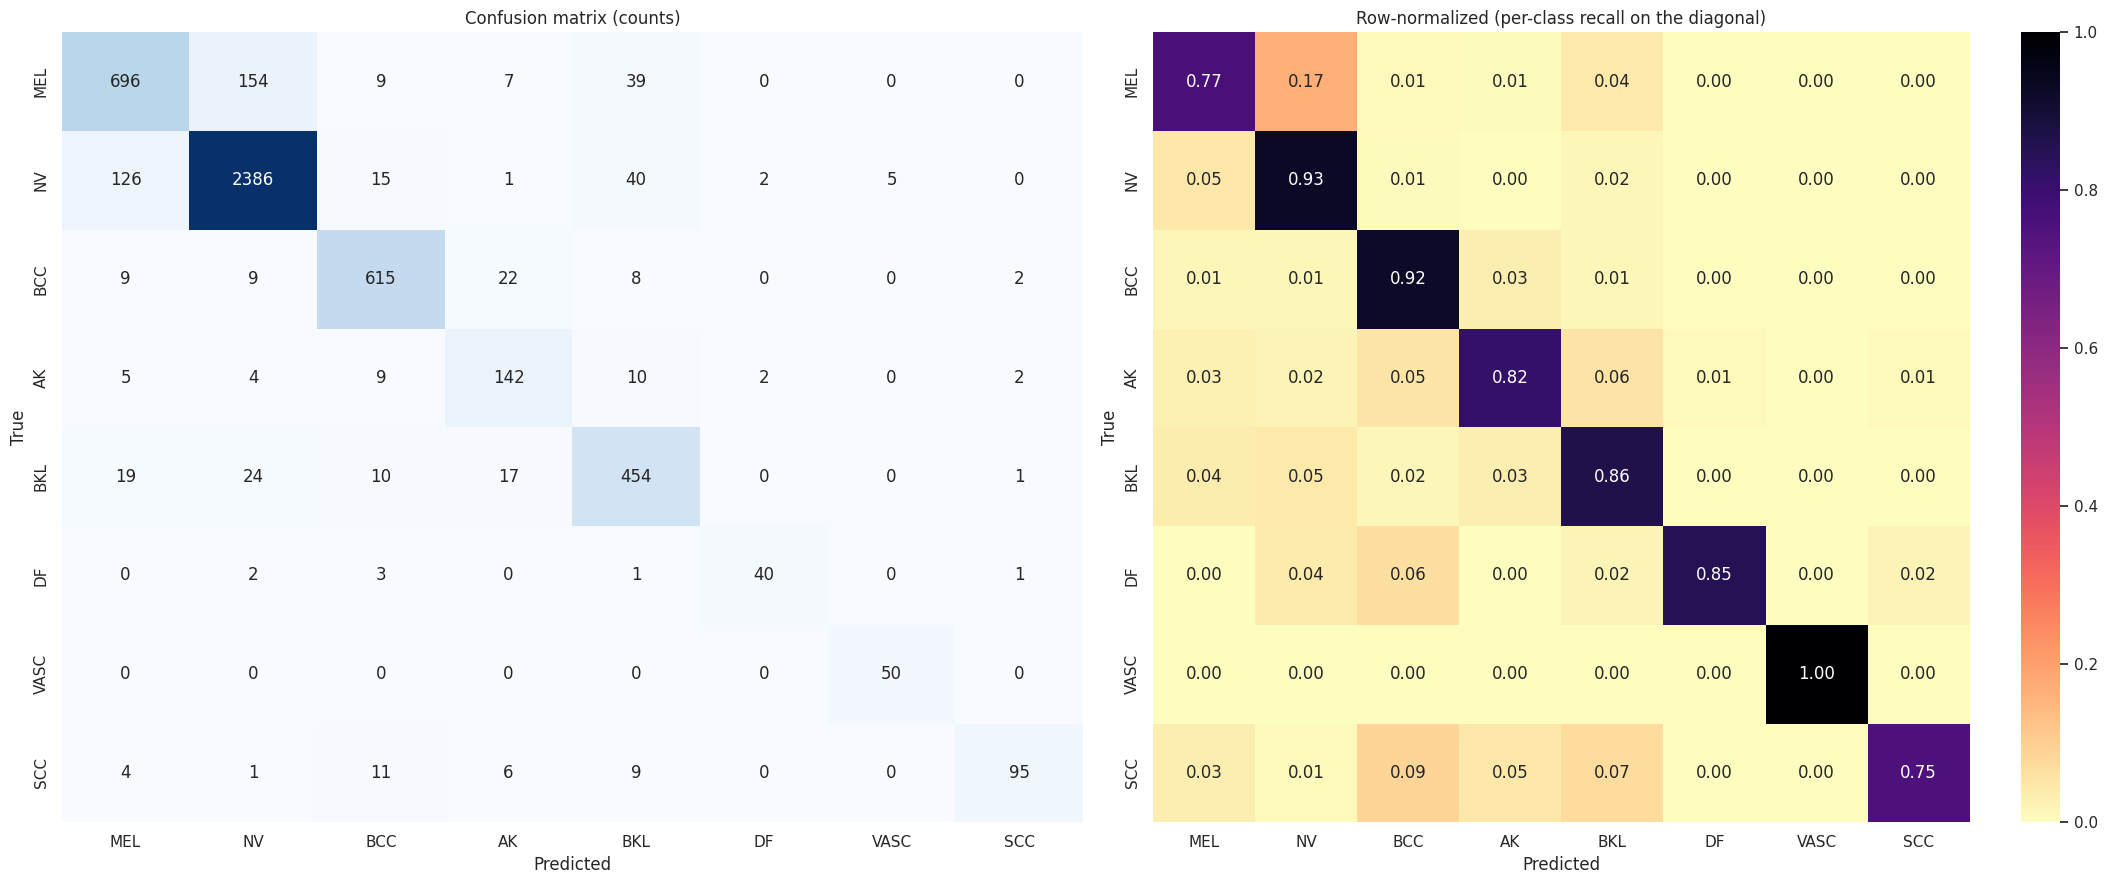

In [27]:
def tune_class_priors(
    y_true: np.ndarray, y_prob: np.ndarray, rounds: int = 3
) -> Tuple[np.ndarray, float]:
    """Coordinate ascent over per-class log-priors to maximize macro F1."""
    log_probs = np.log(np.clip(y_prob, 1e-9, 1.0))
    priors = np.zeros(y_prob.shape[1], dtype=np.float64)

    def score(vector: np.ndarray) -> float:
        preds = (log_probs + vector).argmax(axis=1)
        return f1_score(y_true, preds, average="macro", zero_division=0)

    best = score(priors)
    grid = np.linspace(-1.5, 1.5, 31)

    for _ in range(rounds):
        improved = False
        for class_index in range(len(priors)):
            original = priors[class_index]
            for value in grid:
                priors[class_index] = value
                candidate = score(priors)
                if candidate > best + 1e-6:
                    best, original, improved = candidate, value, True
            priors[class_index] = original
        if not improved:
            break

    return priors, best


priors, tuned_macro_f1 = tune_class_priors(y_true, y_prob)
y_pred_tuned = (np.log(np.clip(y_prob, 1e-9, 1.0)) + priors).argmax(axis=1)

comparison = pd.DataFrame(
    {
        "argmax": pd.Series(compute_metrics(y_true, y_prob, TARGET_CLASSES)),
        "prior-adjusted": pd.Series(
            {
                "accuracy": accuracy_score(y_true, y_pred_tuned),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred_tuned),
                "macro_f1": f1_score(y_true, y_pred_tuned, average="macro", zero_division=0),
                "weighted_f1": f1_score(y_true, y_pred_tuned, average="weighted", zero_division=0),
                "kappa": cohen_kappa_score(y_true, y_pred_tuned, weights="quadratic"),
                "macro_auc": compute_metrics(y_true, y_prob, TARGET_CLASSES)["macro_auc"],
            }
        ),
    }
)
display(comparison.round(4))
print("tuned log-priors:", dict(zip(TARGET_CLASSES, np.round(priors, 3))))
np.save(CFG.checkpoint_dir / "class_priors.npy", priors)

print("\nClassification report after prior adjustment:")
print(
    classification_report(y_true, y_pred_tuned, target_names=TARGET_CLASSES, digits=4, zero_division=0)
)
plot_confusion_matrices(y_true, y_pred_tuned, TARGET_CLASSES)

## 19. Ensemble inference

`EnsemblePredictor` loads every fold checkpoint, averages TTA-smoothed probabilities, and applies the
tuned priors. This is the object you would actually ship.

Loaded 1 model(s) for ensembling.
Ground truth: BCC


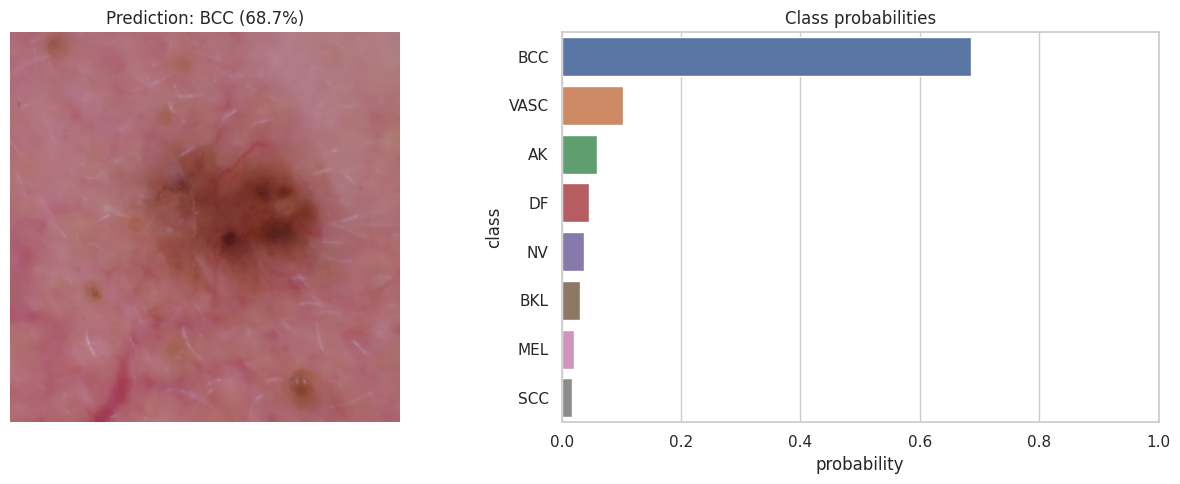

,class,probability
0,BCC,0.6866
1,VASC,0.1026
2,AK,0.0594
3,DF,0.0464
4,NV,0.0378
5,BKL,0.0304
6,MEL,0.0201
7,SCC,0.0166


In [28]:
class EnsemblePredictor:
    """Multi-fold, TTA-averaged, prior-adjusted inference."""

    def __init__(
        self,
        checkpoints: Sequence[Path],
        config: Config,
        class_priors: Optional[np.ndarray] = None,
    ) -> None:
        if not checkpoints:
            raise ValueError("At least one checkpoint is required.")
        self.models = [load_checkpoint(Path(path), config) for path in checkpoints]
        self.config = config
        self.transforms = get_valid_transforms(config.image_size)
        self.priors = np.zeros(NUM_CLASSES) if class_priors is None else class_priors
        print(f"Loaded {len(self.models)} model(s) for ensembling.")

    @torch.no_grad()
    def predict_batch(self, tensor: torch.Tensor) -> np.ndarray:
        """Average softmax over models and TTA views for a preprocessed NCHW batch."""
        tensor = tensor.to(DEVICE, non_blocking=True)
        if self.config.channels_last and DEVICE.type == "cuda":
            tensor = tensor.contiguous(memory_format=torch.channels_last)

        views = self.config.tta_transforms if self.config.use_tta else 1
        accumulated = torch.zeros(tensor.size(0), NUM_CLASSES, device=DEVICE, dtype=torch.float32)

        for model in self.models:
            for view in range(views):
                with autocast_ctx(AMP_ENABLED):
                    logits = model(dihedral(tensor, view))
                accumulated += torch.softmax(logits.float(), dim=1)

        probs = (accumulated / (len(self.models) * views)).cpu().numpy()
        adjusted = np.log(np.clip(probs, 1e-9, 1.0)) + self.priors
        return np.exp(adjusted) / np.exp(adjusted).sum(axis=1, keepdims=True)

    def predict_image(self, image_path: str, show: bool = True) -> pd.DataFrame:
        """Predict a single file and optionally plot the image with its top classes."""
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Unreadable image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        tensor = self.transforms(image=image)["image"].unsqueeze(0)
        probs = self.predict_batch(tensor)[0]

        table = (
            pd.DataFrame({"class": TARGET_CLASSES, "probability": probs})
            .sort_values("probability", ascending=False)
            .reset_index(drop=True)
        )

        if show:
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            axes[0].imshow(image)
            axes[0].axis("off")
            axes[0].set_title(f"Prediction: {table.loc[0, 'class']} ({table.loc[0, 'probability']:.1%})")
            sns.barplot(data=table, y="class", x="probability", ax=axes[1], hue="class", legend=False)
            axes[1].set_xlim(0, 1)
            axes[1].set_title("Class probabilities")
            plt.tight_layout()
            plt.show()

        return table


ensemble = EnsemblePredictor(
    [result["checkpoint"] for result in fold_results], CFG, class_priors=priors
)

sample = df_data.sample(1, random_state=7).iloc[0]
print("Ground truth:", sample["label_str"])
display(ensemble.predict_image(sample["image_path"]).round(4))

## 20. Where the remaining points are

Ranked by return on GPU hours:

1. **Run all 5 folds.** Ensembling is the single largest gain, usually +2-3 points macro F1.
2. **Backbone diversity.** Train one `convnext_base` plus one `tf_efficientnetv2_m` or `swin_base_patch4_window7_224`, then average. Different inductive biases make different mistakes.
3. **Resolution ladder.** Fine-tune the last few epochs at 384 or 448. Small lesions live in high-frequency detail.
4. **External data.** HAM10000 and BCN20000 overlap heavily with ISIC 2019 and boost DF/VASC/SCC. Deduplicate by lesion id, or you will leak.
5. **Group-aware splits.** ISIC has multiple images per lesion. If you get lesion ids, switch `StratifiedKFold` to `StratifiedGroupKFold` grouped on lesion. Ignoring this inflates every metric.
6. **Metadata fusion.** Age, sex, and anatomical site add real signal; concatenate them into the head.
7. **Calibrate before deploying.** Temperature scaling on OOF, since focal loss and heavy class weighting both leave the model badly calibrated.

**On the 90% target:** weighted F1 and accuracy above 0.90 are very reachable here. Macro F1 at 0.90 across
all 8 classes is not, without external data and group-safe splits. Report both, and be suspicious of any
notebook that only shows you accuracy.